# Theorem 2

Exploration of the trascendetal equation 
$$ 
    \exp{(-\gamma P_2)} = \frac{\alpha}{\kappa} \cdot \frac{1-P_2}{P_2 + \beta}
$$

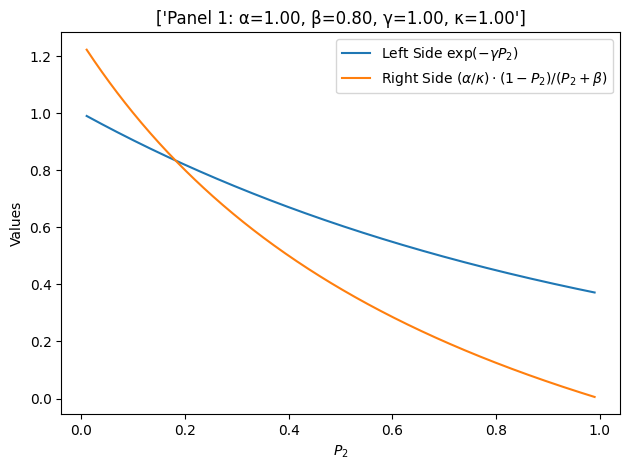

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Button, RadioButtons, HBox, VBox

# Define the transcendental functions for the left and right sides of the equation
def left_side(P2, gamma):
    return np.exp(-gamma * P2)

def right_side(P2, alpha, kappa, beta):
    return (alpha / kappa) * ((1 - P2) / (P2 + beta))

# Plotting function
def plot_transcendental(alpha, beta, gamma, kappa, panel):
    P2 = np.linspace(0.01, 0.99, 400)  # Avoid division by zero or undefined behaviors
    plt.figure()

    title = [
        f"Panel 1: α={alpha:.2f}, β={beta:.2f}, γ={gamma:.2f}, κ={kappa:.2f}"
    ]
        
    a = alpha 
    b = beta 
    g = gamma 
    k = kappa 
    
    plt.plot(P2, left_side(P2, g), label='Left Side $\exp(-\gamma P_2)$')
    plt.plot(P2, right_side(P2, a, k, b), label='Right Side $(\\alpha/\\kappa) \\cdot (1-P_2)/(P_2 + \\beta)$')
    plt.title(title)
    plt.xlabel('$P_2$')
    plt.ylabel('Values')
    plt.legend()
        
    plt.tight_layout()
    plt.show()

# Interaction function
def interactive_plot():
    style = {'description_width': 'initial'}
    alpha_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Alpha (α):', style=style)
    beta_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Beta (β):', style=style)
    gamma_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Gamma (γ):', style=style)
    kappa_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Kappa (κ):', style=style)
    panel_selector = RadioButtons(options=[('Panel 1', 1), ('Panel 2', 2), ('Panel 3', 3), ('Panel 4', 4)], description='Select Panel:')
    plot_button = Button(description="Generate PNG")

    ui = VBox([
        HBox([alpha_slider, beta_slider]),
        HBox([gamma_slider, kappa_slider]),
        panel_selector,
        plot_button
    ])

    def on_button_clicked(b):
        plot_transcendental(alpha_slider.value, beta_slider.value, gamma_slider.value, kappa_slider.value, panel_selector.value)
        plt.savefig('Theorem2.png')
    
    plot_button.on_click(on_button_clicked)

    return ui

# Display interactive widgets
interactive_plot()


# Alternative system

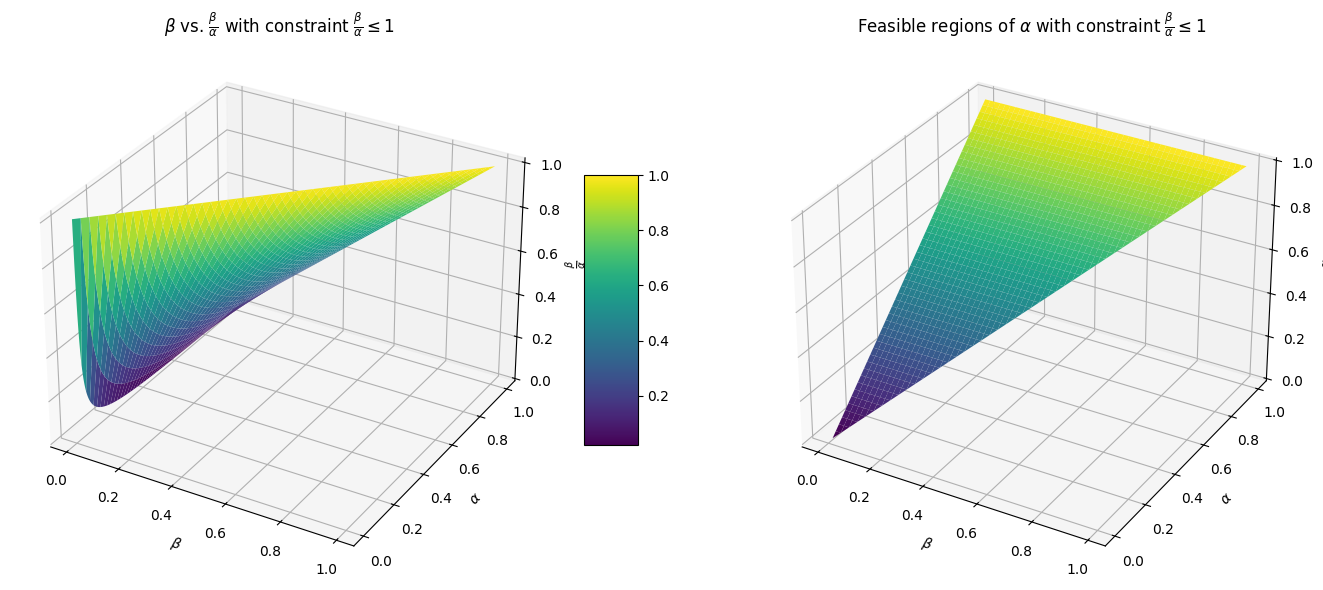

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of beta and alpha
beta = np.linspace(0.01, 0.99, 400)
alpha = np.linspace(0.01, 0.99, 400)

# Create a meshgrid for beta and alpha
B, A = np.meshgrid(beta, alpha)

# Compute the values of beta/alpha for each combination of beta and alpha
Z = B / A

# Apply the constraint beta/alpha <= 1
Z_constrained = np.where(Z <= 1, Z, np.nan)

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

# First subplot: Surface plot with constraint beta/alpha <= 1
surf = ax1.plot_surface(B, A, Z_constrained, cmap='viridis')
ax1.set_title(r'$\beta$ vs. $\frac{\beta}{\alpha}$ with constraint $\frac{\beta}{\alpha} \leq 1$')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel(r'$\alpha$')
ax1.set_zlabel(r'$\frac{\beta}{\alpha}$')

# Add a color bar to the first subplot
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Second subplot: Feasible regions of alpha
# Creating a mask to highlight feasible alpha regions
feasible_alpha = np.where(Z <= 1, A, np.nan)

ax2.plot_surface(B, A, feasible_alpha, cmap='viridis')
ax2.set_title(r'Feasible regions of $\alpha$ with constraint $\frac{\beta}{\alpha} \leq 1$')
ax2.set_xlabel(r'$\beta$')
ax2.set_ylabel(r'$\alpha$')
ax2.set_zlabel(r'$\alpha$')

# Show the plots
plt.tight_layout()
plt.show()
